<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">

# Assembly-to-Assembly Similarity Search Using HOOPS Embeddings

This notebook extends [`demo_HOOPS_Embeddings_retrieval.ipynb`](./demo_HOOPS_Embeddings_retrieval.ipynb)
from **part** retrieval to **assembly** retrieval.

HOOPS Embeddings already splits an assembly into its bodies (one embedding per body). Here we
add an `AssemblyMatcher` that, given a query assembly, returns the most similar **assemblies**
in the indexed corpus.

## Why this works out of the box

When a corpus is indexed, the library stores **one vector per body** and uses the
**source file path as the id**, repeated once per body. So:

- a multi-body assembly appears as **several rows that share the same id**;
- the number of rows for an id **is that assembly's part/body count** — this is the "assembly
  count" flag, recoverable directly from the loaded `EmbeddingBatch`;
- a returned `VectorHit.id` **is the assembly** the matched part belongs to.

## Pipeline

1. **Load** the FAISS index → `EmbeddingBatch` (vectors + ids).
2. **Enumerate assemblies** = ids that occur more than once (multi-body files).
3. **Stage 1 — candidate generation:** per-part FAISS search → union of candidate assemblies.
4. **Stage 2 — verification:** for each candidate, score with an optimal one-to-one
   (Hungarian) part matching + optional TF-IDF rare-part weighting.
5. **Rank** and return the top-K assemblies.

## Inside Stage 2 — how a candidate is scored

Stage 1 is fast but only asks *"does this candidate share some parts with the query?"* Stage 2 is
the careful check: it lines up the two parts lists and decides how good the overall match really
is. Think of it like a **bill-of-materials comparison** done on shape, not part numbers.

<img src="../images/stage2_matching.svg" alt="Stage 2 optimal part matching diagram" style="width: 100%; max-width: 1000px;">

**Read it left to right:**

1. **Match parts one-to-one.** Every query part is paired with at most one candidate part, and
   vice-versa — exactly like fitting parts on an assembly bench, where one bolt fits one hole.
   The similarity of each pair is the cosine of their HOOPS Embedding vectors (1.0 = identical
   shape). A pair only "counts" if its similarity clears `sim_thresh` (default **0.80**).
2. **Pick the best total assignment.** Build the full query×candidate similarity table and choose
   the set of pairs that **maximizes the total similarity**, with the hard constraint of one pick
   per row and per column. This optimal assignment is the classic **Hungarian algorithm** — it
   avoids greedy mistakes and stops a single generic bolt from being matched many times.
3. **Weight by rarity, then combine.** Common hardware (bolts, washers, nuts) appears in almost
   every assembly, so it carries little discriminating power and gets a **low TF-IDF weight**;
   distinctive parts (a specific housing, gear, or bracket) get a **high weight**. The
   **geometric score** multiplies *match quality* (rarity-weighted mean similarity of the matched
   pairs) by *coverage* (the rarity-weighted fraction of the assembly that is matched, by default
   normalized by the larger assembly so a big library can't trivially "contain" a small query).
4. **Blend in composition.** Independently, each assembly is summarized as a **bag-of-parts** —
   a rarity-weighted histogram of which part-clusters it contains and how many of each. The cosine
   of two such histograms is the *composition score*. The final `score` blends the geometric and
   composition scores (`bop_weight`, default **0.3**; set to `0` for geometry only).

In short: **two assemblies score high only when their distinctive parts line up one-for-one, most
of the parts are accounted for, and the overall part mix agrees** — which is one strategy for how an
engineer would judge whether two assemblies are "the same thing."


In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.1.0  (build: ed23c844 2026-06-12T14:14:13Z)
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-06-12T10:38:16Z)
  Conversion    : hoops-converter      26.1.1  (build: 00dc9f6 2026-06-12T10:22:46Z)
  Insights      : hoops-web-viewer     26.1.1  (build: d30058f 2026-06-12T10:22:25Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


## 1. Configure paths

Set the model checkpoint and the FAISS index. Both live under `packages/` — one level above
this notebook. Use an index built from a corpus that **contains assemblies** (multi-body
files); a parts-only index will report zero assemblies in step 3.

In [2]:
from hoops_ai.ml.embeddings import HOOPSEmbeddings, Embedding, EmbeddingBatch
import pathlib

packages_dir = pathlib.Path.cwd().parent.joinpath("packages")

pretrained_model = packages_dir.joinpath("trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt")

# Point this at an index that contains assemblies (multi-body files).
indexed_database = packages_dir.joinpath("vectorstores","tmcad","TMCAD_SIGNAL.faiss")

if not indexed_database.exists():
    sys.exit(f"Index not found: {indexed_database}. Build one with demo_HOOPS_Embeddings_indexing.ipynb on an assembly corpus.")

## 2. Register the model and load the index

In [3]:
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pretrained_model),
)
embedder = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview")
print(f"Using model: {embedder.model_name} (dim={embedder.embedding_dim})")

Successfully loaded model from checkpoint: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt
Using model: HOOPS Embeddings SIGNAL preview (dim=2048)


c:\Users\LuisSalazar.LY-LS-LEGION\Documents\hoops-ai-packages-test\.venv\Lib\site-packages\pytorch_lightning\utilities\parsing.py:136: pytorch_lightning save_hyperparameters: frame introspection failed. Nuitka-compiled frames have empty locals, which breaks PL's collect_init_args. Pass an explicit dict to save_hyperparameters() for correct hparams under Nuitka.


In [4]:
from hoops_ai.ml import CADSearch

searcher = CADSearch(shape_model=embedder)
embeddingBatch = searcher.load_shape_index(path=str(indexed_database))

print(f"Source model: {embeddingBatch.model}")
print(f"Loaded {len(embeddingBatch.ids)} body embeddings (dim={embeddingBatch.values.shape[1]}).")

Source model: CUSTOM:HOOPS Embeddings SIGNAL preview
Loaded 39736 body embeddings (dim=2048).


## 3. Find all assemblies in the vector store

Each row is one body; the id is the source file. The number of rows sharing an id is that
file's **body count**. Files with `body_count >= 2` are the assemblies.

In [5]:
from collections import Counter

id_counts = Counter(embeddingBatch.ids)                       # id -> body/part count

assemblies = {fid: n for fid, n in id_counts.items() if n >= 2}
single_part_files = {fid: n for fid, n in id_counts.items() if n == 1}

print(f"Files in index:     {len(id_counts)}")
print(f"  assemblies (>=2 bodies): {len(assemblies)}")
print(f"  single-part files:       {len(single_part_files)}")

print("\nLargest assemblies (id, body_count):")
for fid, n in sorted(assemblies.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {n:4d}  {pathlib.Path(fid).name}")

Files in index:     10848
  assemblies (>=2 bodies): 2450
  single-part files:       8398

Largest assemblies (id, body_count):
   494  795.stp
   447  941.stp
   367  437.stp
   206  983.stp
   202  455.stp
   202  225.stp
   194  1085.stp
   193  977.stp
   187  290.stp
   165  38.stp


## 4. The `AssemblyMatcher`

The matcher lives in [`assembly_matcher.py`](assembly_matcher.py) next to this notebook and is
imported below. Grouping is done once from the loaded `EmbeddingBatch`; each query then runs
Stage 1 (FAISS shortlist) + Stage 2 (per-candidate verification).

**Scoring** — each candidate's final `score` blends two complementary views:
- **Geometric match (`geom`)** — `method="hungarian"` (default): optimal **one-to-one** matching
  between query and candidate parts (each query part covered at most once). It multiplies *match
  quality* (rarity-weighted mean cosine of matched pairs) by *coverage* (how much of the assembly
  is matched). `method="voting"` is the faster, greedy alternative that can double-count.
- **Composition match (`bop`)** — a **bag-of-parts** TF-IDF histogram over part-clusters (each
  assembly as a "document", each part-cluster a "word"). Its cosine captures whether two
  assemblies share the same *mix and counts* of parts, independent of fine geometric pairing.
- `bop_weight` blends the two (`score = (1-bop_weight)·geom + bop_weight·bop`); `0` = geometry only.

**Knobs**
- All vectors are L2-normalized → similarities are cosine in `[-1, 1]`.
- `use_idf=True`: TF-IDF rare-part weighting — common parts (fasteners, washers) are down-weighted
  so distinctive parts drive both the geometric and composition scores.
- `coverage_mode`: `"symmetric"` (default, normalize by the larger assembly), `"containment"`
  (normalize by the query — find assemblies that *contain* it), or `"jaccard"`.


### Controlling sub-assembly vs. whole-assembly matches — `coverage_mode`

Coverage is computed as `matched_mass / denominator`. The `coverage_mode` argument to
`search()` changes that **denominator**, which directly controls whether you treat the query as a
sub-assembly of larger candidates, or insist on whole-assembly equivalence. Pass it like any other
search knob, e.g. `matcher.search(query, coverage_mode="jaccard")`.

| `coverage_mode` | Denominator | Favors | Sub-assembly behavior |
|---|---|---|---|
| `"containment"` | query mass (`total_q`) | Candidates that **contain** the query | Treats the query as a **sub-assembly** — a big candidate that includes all the query's parts scores high, even with lots of extra parts. |
| `"symmetric"` (default) | `max(total_q, total_c)` | Assemblies of **similar scope** | Penalizes size mismatch in **both** directions — a candidate much bigger or much smaller than the query loses coverage. |
| `"jaccard"` | union (`total_q + total_c − matched`) | **Whole-assembly equivalence** | Strictest — any extra parts on **either** side hurt the score, so both sub- and super-assemblies are pushed down. |

Rule of thumb: use `"containment"` to find the larger assemblies a part/sub-assembly belongs to,
`"jaccard"` to find assemblies that are essentially the *same thing* (same kind **and** size), and
the default `"symmetric"` for a balanced "similar assembly" search.


In [ ]:
from assembly_matcher import AssemblyMatcher

demo_coverage_mode = "symmetric"   # "symmetric" (default) | "containment" | "jaccard"


## 5. Build the matcher

`searcher` already holds the loaded index, so the matcher derives everything from it: the corpus
vectors (Stage-2 scoring + IDF), the fast Stage-1 shortlist, and the shape model used to embed any
out-of-corpus query. `build_part_rarity_weights()` prepares the inverse-document-frequency (TF-IDF)
rare-part weighting table.

In [7]:
matcher = AssemblyMatcher(
    searcher=searcher,
    min_bodies_for_assembly=2,
)
import time

t0 = time.perf_counter()
matcher.build_part_rarity_weights()   # rare-part (TF-IDF) weighting table
elapsed = time.perf_counter() - t0

print(f"Inversed Part frequency built in {elapsed:.3f} s")

print(f"Ready over {len(matcher.assemblies)} assemblies.")

Inversed Part frequency built in 7.546 s
Ready over 2450 assemblies.


## 6. Find the top-K assemblies for a query assembly

We walk through one example in detail: the coupling assembly `341.stp`. It retrieves a clean
neighborhood of other **couplings** — including `188.stp`, `890.stp`, and `944.stp` — even though
none is an exact copy. The query itself is excluded from its own results. To use your own file,
set `query_assembly` to any assembly path (Option B).

In [8]:
# Option A: feature the coupling assembly 341.stp (close to couplings 188/890/944).
query_assembly = next(
    fid for fid in matcher.assemblies
    if fid.replace("\\", "/").endswith("coupling/341.stp")
)

# Option B: point at any assembly file instead.
# query_assembly = str(packages_dir / "cadfiles" / "my_query_assembly.jt")

print(f"Query assembly: {pathlib.Path(query_assembly).name}  ({matcher._counts[query_assembly]} parts)")

results = matcher.search(
    query_path=query_assembly,
    top_k=10,
    candidate_k=10,       # Stage-1 shortlist depth per query part
    sim_thresh=0.80,      # min cosine similarity to count a part as matched
    method="hungarian",   # "hungarian" (recommended) or "voting"
    use_idf=True,         # TF-IDF rare-part weighting
    candidate_mode="search",  # "search" (fast) or "all" (brute force, small corpora)
    assemblies_only=True,
    coverage_mode=demo_coverage_mode,
    n_jobs=8,             # thread Stage-2 scoring across candidates
)

Query assembly: 341.stp  (13 parts)


In [9]:
print(f"Top {len(results)} assemblies similar to {pathlib.Path(query_assembly).name}\n")
print(f"{'rank':>4}  {'score':>6}  {'geom':>5}  {'bop':>5}  {'cover':>6}  {'matched':>8}  {'parts':>5}  assembly")
print("-" * 92)
for rank, r in enumerate(results, 1):
    print(f"{rank:>4}  {r['score']:>6.3f}  {r['geom_score']:>5.3f}  {r['bop_sim']:>5.3f}  "
          f"{r['coverage']:>6.2f}  {r['matched']:>3}/{r['M']:<4}  {r['n_parts']:>5}  {pathlib.Path(r['assembly']).name}")


Top 10 assemblies similar to 341.stp

rank   score   geom    bop   cover   matched  parts  assembly
--------------------------------------------------------------------------------------------
   1   0.216  0.249  0.141    0.28    4/13       13  891.stp
   2   0.212  0.215  0.204    0.24    3/13       13  383.stp
   3   0.182  0.153  0.250    0.16    2/13       13  215.stp
   4   0.129  0.128  0.132    0.14    2/13       13  550.stp
   5   0.128  0.182  0.000    0.22    3/13        9  459.stp
   6   0.115  0.065  0.232    0.07    1/13        3  296.stp
   7   0.092  0.132  0.000    0.15    2/13        9  188.stp
   8   0.092  0.132  0.000    0.15    2/13        8  700.stp
   9   0.091  0.129  0.000    0.14    2/13       13  358.stp
  10   0.090  0.128  0.000    0.15    2/13       11  944.stp


## 7. (Optional) Visualize the matched assemblies

Reuse the same `DatasetViewer` as the part-retrieval demo. Each matched assembly is shown via a
representative body thumbnail captured during Stage 1. Requires a rendered-image folder
alongside the index; safe to skip if unavailable.

Reusing 10 existing PNGs and generating 0 PNGs using persistent process pool...


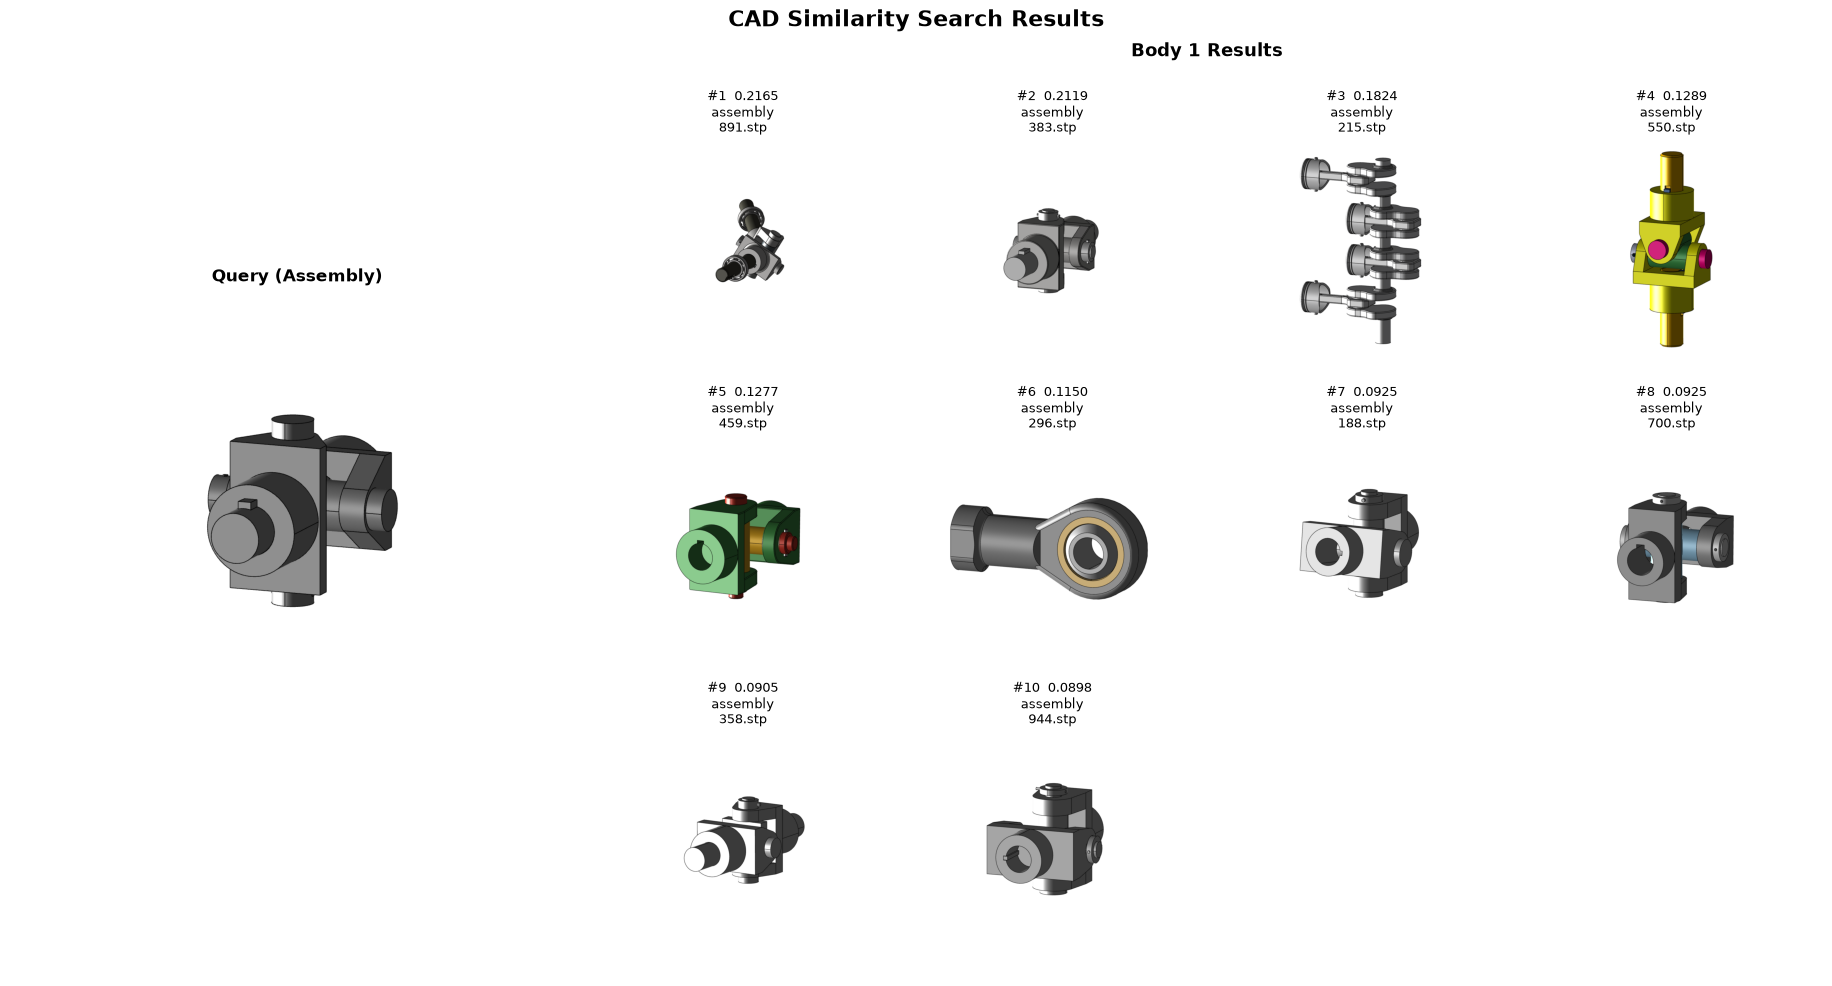

In [10]:
try:
    from hoops_ai.insights import DatasetViewer
    from hoops_ai.ml.embeddings import VectorHit

    images_dir = packages_dir.joinpath("vectorstores", "tmcad", "images_tmcad")
    ds_viewer = DatasetViewer([], [], [], reference_dir=images_dir)

    hits = [
        VectorHit(id=r["assembly"], score=r["score"], metadata=r["display_metadata"] or {})
        for r in results
    ]
    ds_viewer.show_search_results(hits, query_file=query_assembly, grid_cols=4)
except Exception as exc:
    print(f"Visualization skipped ({type(exc).__name__}: {exc}). The ranked table above is the result.")

## 8. Curated demo gallery — hand-picked queries

A hand-picked set of query assemblies (`demo_assemblies`) that each retrieve a clean
neighborhood. Each entry is a **unique path suffix** (`"parent/file.stp"`) so it resolves to
exactly one assembly. The helper below resolves an identifier, runs the search, prints the ranked
table, and shows the query plus its top matches as a thumbnail grid.

Run the featured demos one at a time in the cells that follow, or call
`show_assembly_matches("parent/file.stp")` with any entry from `demo_assemblies` (or your own
file) to explore others.


In [14]:
from hoops_ai.insights import DatasetViewer
from hoops_ai.ml.embeddings import VectorHit

images_dir = packages_dir.joinpath("vectorstores", "tmcad", "images_tmcad")
ds_viewer = DatasetViewer([], [], [], reference_dir=images_dir)

# Hand-picked query assemblies with clean neighborhoods. Each identifier is a unique path
# suffix (parent folder + filename) so it resolves to exactly one assembly.
demo_assemblies = [
    "coupling/255.stp", "140.stp", "bearing/201.stp", "coupling/68.stp", "394.stp",
    "bearing/287.stp", "146.stp", "bearing/291.stp", "gear/1000.stp", "89.stp",
    "bearing/163.stp", "bearing/170.stp", "bearing/344.stp", "pulley/241.stp", "115.stp",
    "coupling/305.stp", "bearing/424.stp", "bearing/314.stp", "bearing/88.stp", "bearing/761.stp",
    "bearing/392.stp", "980.stp", "bearing/765.stp", "304.stp", "bearing/47.stp",
    "coupling/257.stp", "pulley/700.stp", "coupling/81.stp", "56.stp", "bearing/772.stp",
    "bearing/678.stp", "pulley/461.stp", "bearing/59.stp", "bearing/968.stp", "bearing/845.stp",
    "bearing/771.stp", "741.stp", "pulley/187.stp", "bearing/729.stp", "675.stp",
    "coupling/199.stp", "bearing/676.stp", "coupling/53.stp", "bearing/153.stp", "coupling/317.stp",
    "677.stp", "pulley/928.stp", "coupling/955.stp", "bearing/446.stp", "bearing/341.stp",
]

def resolve_assembly(rel_id):
    """Full corpus id whose path ends with the given relative identifier."""
    key = rel_id.replace("\\", "/")
    return next(
        fid for fid in matcher.assemblies
        if fid.replace("\\", "/").endswith(key)
    )

def show_assembly_matches(rel_id, top_k=4, candidate_k=30, coverage_mode=demo_coverage_mode):
    """Resolve one query identifier, search, print the ranked table, and show the thumbnail grid."""
    query_assembly = resolve_assembly(rel_id)
    results = matcher.search(query_assembly, top_k=top_k, candidate_k=candidate_k,
                             method="hungarian", use_idf=True, n_jobs=8,
                             coverage_mode=coverage_mode)
    print(f"Query: {pathlib.Path(query_assembly).name}  ({matcher._counts[query_assembly]} parts)")
    for rank, r in enumerate(results, 1):
        print(f"   {rank}. {pathlib.Path(r['assembly']).name:>10}  "
              f"score={r['score']:.3f}  cover={r['coverage']:.2f}  parts={r['n_parts']}")
    hits = [
        VectorHit(id=r["assembly"], score=r["score"], metadata=r["display_metadata"] or {})
        for r in results
    ]
    ds_viewer.show_search_results(hits, query_file=query_assembly, grid_cols=4)


Query: 255.stp  (42 parts)
   1.    238.stp  score=0.991  cover=1.00  parts=42
   2.    220.stp  score=0.978  cover=1.00  parts=42
   3.    256.stp  score=0.973  cover=1.00  parts=42
   4.    259.stp  score=0.806  cover=0.74  parts=32
Reusing 4 existing PNGs and generating 0 PNGs using persistent process pool...


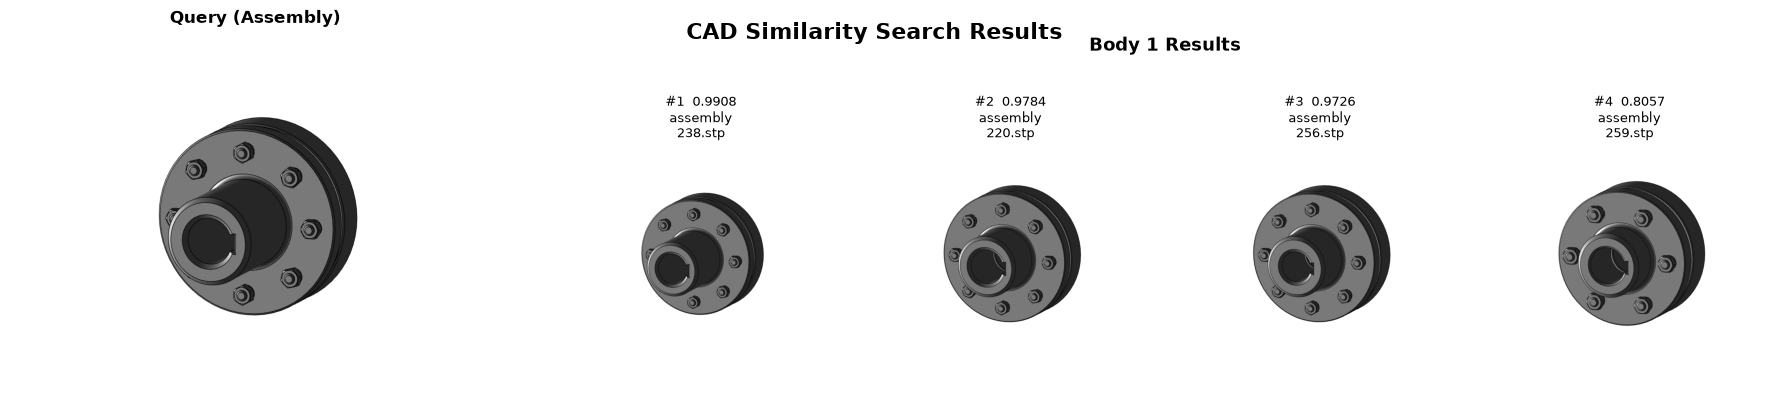

In [15]:
show_assembly_matches("coupling/255.stp")


In [ ]:
show_assembly_matches("140.stp")


In [ ]:
show_assembly_matches("bearing/201.stp")


In [ ]:
show_assembly_matches("115.stp")


In [ ]:
show_assembly_matches("coupling/68.stp")


In [ ]:
show_assembly_matches("bearing/287.stp")


In [ ]:
show_assembly_matches("89.stp")


In [ ]:
show_assembly_matches("pulley/700.stp")


In [ ]:
show_assembly_matches("coupling/81.stp")


In [ ]:
show_assembly_matches("bearing/729.stp")


In [ ]:
show_assembly_matches("675.stp")


In [ ]:
show_assembly_matches("bearing/163.stp")


**Recall:** all part vectors are L2-normalized, so scores are cosine similarities in `[-1, 1]`. The
final `score` blends a **geometric** Hungarian match (rarity-weighted mean similarity × coverage,
size-normalized so a large library assembly cannot trivially "contain" a small query) with a
**bag-of-parts** composition score (how alike the two assemblies' part mix and counts are).
